In [1]:
import ipaddress
import pandas as pd
import matplotlib.pyplot as plt

# Keep consistent with recon/modbus notebooks
TIME_OFFSET = 10800

In [2]:
import os
def ping ():
    os.system('notify-send "Python Script" "Execution complete!"')

In [3]:
def plot_packet_count_per_dst_ip(
    input_csv,
    dst_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
    debug=False,
):
    """
    1) Plot packet_count per dst IP in 1-second bins for
    [center_timestamp - interval_seconds, center_timestamp + interval_seconds].

    If debug=True, print the peak bin and aligned timestamp span.
    """
    cols = ["ip.dst", "frame.time_epoch"]
    ipaddress.ip_address(dst_ip)
    df = pd.read_csv(input_csv, usecols=lambda c: c in cols)

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    dst_df = df[df["ip.dst"].astype(str) == dst_ip].copy()
    window_df = dst_df[(dst_df["aligned_ts"] >= start_ts) & (dst_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin").size().reindex(bins, fill_value=0)

    if debug:
        if window_df.empty:
            print(f"No rows in window for dst={dst_ip}.")
        else:
            peak_idx = series.idxmax()
            peak_value = int(series.max())
            peak_offset = int((peak_idx - center_second).total_seconds())
            print(f"Aligned window: {window_df['aligned_ts'].min()} -> {window_df['aligned_ts'].max()}")
            print(f"Peak bin: {peak_idx} ({peak_offset:+d} s from center)")
            print(f"Peak packet_count: {peak_value}")
            print(f"Rows in window: {len(window_df)}")

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("packet_count")
    plt.title(f"Packet count for dst={dst_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ping()
    return series


def plot_sum_tcp_len_per_dst_ip(
    input_csv,
    dst_ip,
    center_timestamp,
    interval_seconds,
    time_offset_seconds=TIME_OFFSET,
    debug=False,
):
    """
    2) Plot sum(tcp.len) per dst IP in 1-second bins.


    If debug=True, print the peak bin and aligned timestamp span.
    """
    ipaddress.ip_address(dst_ip)
    required_cols = {"ip.dst", "frame.time_epoch", "tcp.len"}
    df = pd.read_csv(input_csv, usecols=lambda c: c in required_cols)

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df["tcp.len"] = pd.to_numeric(df["tcp.len"], errors="coerce").fillna(0)

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    dst_df = df[df["ip.dst"].astype(str) == dst_ip].copy()
    window_df = dst_df[(dst_df["aligned_ts"] >= start_ts) & (dst_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["tcp.len"].sum().reindex(bins, fill_value=0)

    if debug:
        if window_df.empty:
            print(f"No rows in window for dst={dst_ip}.")
        else:
            peak_idx = series.idxmax()
            peak_value = float(series.max())
            peak_offset = int((peak_idx - center_second).total_seconds())
            non_zero_tcp_len = int((window_df["tcp.len"] > 0).sum())
            print(f"Aligned window: {window_df['aligned_ts'].min()} -> {window_df['aligned_ts'].max()}")
            print(f"Peak bin: {peak_idx} ({peak_offset:+d} s from center)")
            print(f"Peak sum(tcp.len): {peak_value:.6f}")
            print(f"Rows in window: {len(window_df)}")
            print(f"Rows with tcp.len > 0 in window: {non_zero_tcp_len}")

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel("sum(tcp.len)")
    plt.title(f"Sum of tcp.len for dst={dst_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ping()
    return series


def plot_modbus_response_time_stats_per_dst_ip(
    input_csv,
    dst_ip,
    center_timestamp,
    interval_seconds,
    response_col="modbus.response_time",
    plot_std=True,
    debug=False,
    time_offset_seconds=TIME_OFFSET,
):
    """
    3) Plot mean(modbus.response_time) per dst IP in 1-second bins,
    and optionally its standard deviation.
    """
    ipaddress.ip_address(dst_ip)
    required_cols = {"ip.dst", "frame.time_epoch", response_col}
    df = pd.read_csv(input_csv, usecols=list(required_cols), engine="python", on_bad_lines="skip")
    print(df.columns)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")
    df[response_col] = pd.to_numeric(df[response_col], errors="coerce")

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    dst_df = df[df["ip.dst"].astype(str) == dst_ip].copy()
    window_df = dst_df[(dst_df["aligned_ts"] >= start_ts) & (dst_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    mean_series = window_df.groupby("second_bin")[response_col].mean().reindex(bins)
    std_series = window_df.groupby("second_bin")[response_col].std().reindex(bins)

    if debug:
        non_null_response = int(window_df[response_col].notna().sum())
        print(f"Rows in window: {len(window_df)}")
        print(f"Non-null {response_col} rows in window: {non_null_response}")
        print(f"Window aligned timestamp span: {window_df['aligned_ts'].min()} -> {window_df['aligned_ts'].max()}")
        if non_null_response == 0:
            print(f"Warning: no non-null {response_col} values in the selected window, so the plotted series will be NaN.")
        else:
            peak_idx = mean_series.idxmax()
            peak_value = float(mean_series.max())
            peak_offset = int((peak_idx - center_second).total_seconds())
            print(f"Peak bin (mean): {peak_idx} ({peak_offset:+d} s from center)")
            print(f"Peak mean({response_col}): {peak_value:.6f}")
            if plot_std and std_series.notna().any():
                std_peak_idx = std_series.idxmax()
                std_peak_value = float(std_series.max())
                std_peak_offset = int((std_peak_idx - center_second).total_seconds())
                print(f"Peak bin (std): {std_peak_idx} ({std_peak_offset:+d} s from center)")
                print(f"Peak std({response_col}): {std_peak_value:.6f}")

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, mean_series.values, marker="o", label=f"mean({response_col})")
    if plot_std:
        plt.plot(rel_x, std_series.values, marker="o", label=f"std({response_col})")

    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(response_col)
    plt.title(f"Response-time stats for dst={dst_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ping()
    return mean_series, std_series


def plot_sum_retransmission_per_dst_ip(
    input_csv,
    dst_ip,
    center_timestamp,
    interval_seconds,
    retrans_col="tcp.analysis.retransmission",
    time_offset_seconds=TIME_OFFSET,
    debug=False,
):
    """
    4) Plot sum(tcp.analysis.retransmission) per dst IP in 1-second bins.

    If retrans_col is non-numeric (e.g., text marker), non-empty values are treated as 1.
    If debug=True, print the peak bin and aligned timestamp span.
    """
    ipaddress.ip_address(dst_ip)
    required_cols = {"ip.dst", "frame.time_epoch", retrans_col}
    df = pd.read_csv(input_csv, usecols=list(required_cols), engine="python", on_bad_lines="skip")

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required column(s): {sorted(missing)}")

    epoch = pd.to_numeric(df["frame.time_epoch"], errors="coerce")
    df = df.loc[epoch.notna()].copy()
    df["aligned_ts"] = pd.to_datetime(epoch[epoch.notna()] + float(time_offset_seconds), unit="s", errors="coerce")

    numeric_vals = pd.to_numeric(df[retrans_col], errors="coerce")
    if numeric_vals.notna().any():
        df["retrans_numeric"] = numeric_vals.fillna(0)
    else:
        df["retrans_numeric"] = df[retrans_col].fillna("").astype(str).str.strip().ne("").astype(int)

    center_ts = pd.to_datetime(center_timestamp, errors="raise")
    start_ts = center_ts - pd.Timedelta(seconds=int(interval_seconds))
    end_ts = center_ts + pd.Timedelta(seconds=int(interval_seconds))

    dst_df = df[df["ip.dst"].astype(str) == dst_ip].copy()
    window_df = dst_df[(dst_df["aligned_ts"] >= start_ts) & (dst_df["aligned_ts"] <= end_ts)].copy()
    window_df["second_bin"] = window_df["aligned_ts"].dt.floor("s")

    center_second = center_ts.floor("s")
    bins = pd.date_range(
        start=center_second - pd.Timedelta(seconds=int(interval_seconds)),
        end=center_second + pd.Timedelta(seconds=int(interval_seconds)),
        freq="s",
    )
    rel_x = (bins - center_second).total_seconds().astype(int)

    series = window_df.groupby("second_bin")["retrans_numeric"].sum().reindex(bins, fill_value=0)

    if debug:
        if window_df.empty:
            print(f"No rows in window for dst={dst_ip}.")
        else:
            peak_idx = series.idxmax()
            peak_value = float(series.max())
            peak_offset = int((peak_idx - center_second).total_seconds())
            non_zero_retrans = int((window_df["retrans_numeric"] > 0).sum())
            print(f"Aligned window: {window_df['aligned_ts'].min()} -> {window_df['aligned_ts'].max()}")
            print(f"Peak bin: {peak_idx} ({peak_offset:+d} s from center)")
            print(f"Peak sum({retrans_col}): {peak_value:.6f}")
            print(f"Rows in window: {len(window_df)}")
            print(f"Rows with {retrans_col} > 0 in window: {non_zero_retrans}")

    plt.figure(figsize=(11, 4))
    plt.plot(rel_x, series.values, marker="o")
    plt.axvline(0, color="black", linestyle="--", linewidth=1, label="Target timestamp")
    plt.xlabel("Seconds offset from target timestamp")
    plt.ylabel(f"sum({retrans_col})")
    plt.title(f"Retransmission sum for dst={dst_ip} around {center_ts} (+/-{interval_seconds}s)")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ping()
    return series


# Example usage:
# input_csv = "../train/ext_attack_nw.csv"
# dst_ip = "185.175.0.5"
# center_timestamp = "2023-03-19 03:01:57.813"
# x = 20
#
# plot_packet_count_per_dst_ip(input_csv, dst_ip, center_timestamp, x)
# plot_sum_tcp_len_per_dst_ip(input_csv, dst_ip, center_timestamp, x)
# plot_modbus_response_time_stats_per_dst_ip(input_csv, dst_ip, center_timestamp, x, plot_std=True)
# plot_sum_retransmission_per_dst_ip(input_csv, dst_ip, center_timestamp, x)

Aligned window: 2023-03-18 20:19:05.109796047 -> 2023-03-18 20:52:21.630111933
Peak bin: 2023-03-18 20:21:02 (-883 s from center)
Peak packet_count: 1792
Rows in window: 32741


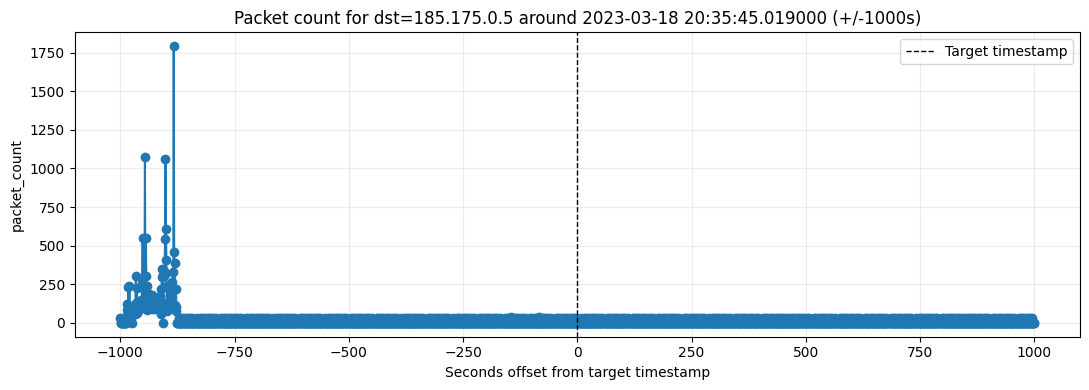

Aligned window: 2023-03-17 00:54:45.989466906 -> 2023-03-17 01:27:59.785640001
Peak bin: 2023-03-17 01:21:20 (+597 s from center)
Peak packet_count: 601
Rows in window: 9010


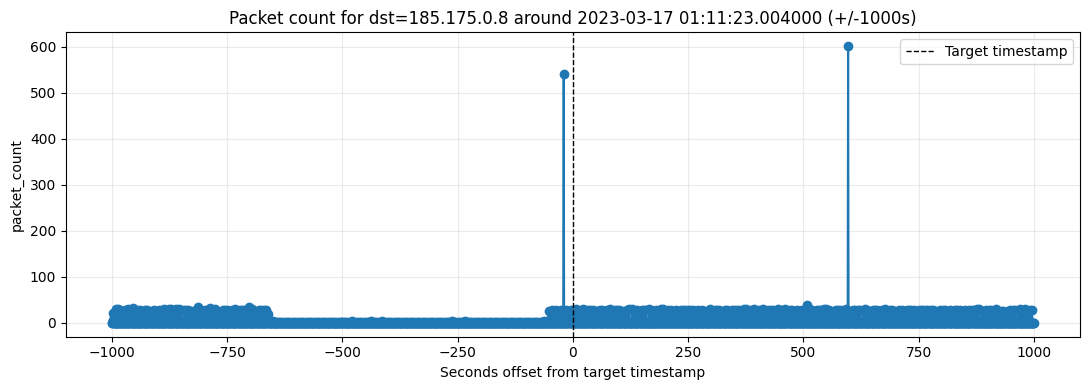

Aligned window: 2023-03-17 02:17:43.133465052 -> 2023-03-17 02:50:59.405507088
Peak bin: 2023-03-17 02:48:58 (+875 s from center)
Peak packet_count: 485
Rows in window: 6051


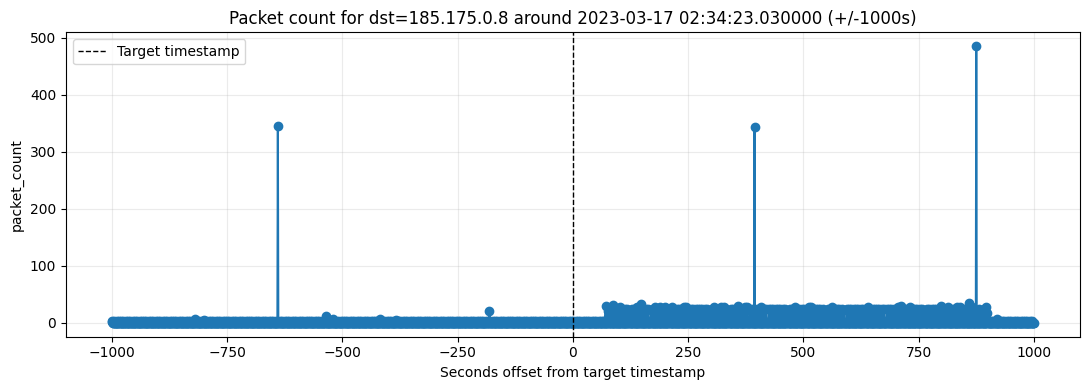

Aligned window: 2023-03-18 00:49:59.721344948 -> 2023-03-18 01:23:17.469978094
Peak bin: 2023-03-18 01:14:02 (+444 s from center)
Peak packet_count: 428
Rows in window: 7394


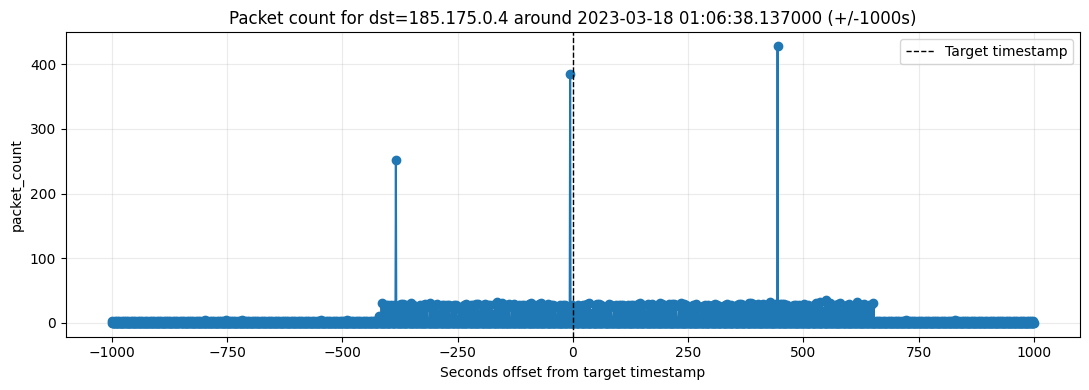

2023-03-18 00:49:58    0
2023-03-18 00:49:59    3
2023-03-18 00:50:00    0
2023-03-18 00:50:01    0
2023-03-18 00:50:02    0
                      ..
2023-03-18 01:23:14    0
2023-03-18 01:23:15    0
2023-03-18 01:23:16    0
2023-03-18 01:23:17    3
2023-03-18 01:23:18    0
Freq: s, Length: 2001, dtype: int64

In [ ]:
plot_packet_count_per_dst_ip("../train/chunks/csc_9.csv", "185.175.0.5", "2023-03-18 20:35:45.019", 1000, debug=True)
plot_packet_count_per_dst_ip("../train/chunks/csc_3.csv", "185.175.0.8", "2023-03-17 01:11:23.004", 1000, debug=True)
plot_packet_count_per_dst_ip("../train/chunks/csc_4.csv", "185.175.0.8", "2023-03-17 02:34:23.03", 1000, debug=True) 
plot_packet_count_per_dst_ip("../train/chunks/csc_6.csv", "185.175.0.4", "2023-03-18 01:06:38.137", 1000, debug=True)

Aligned window: 2023-03-18 20:19:05.109796047 -> 2023-03-18 20:52:21.630111933
Peak bin: 2023-03-18 20:21:02 (-883 s from center)
Peak sum(tcp.len): 4260.000000
Rows in window: 32741
Rows with tcp.len > 0 in window: 6096


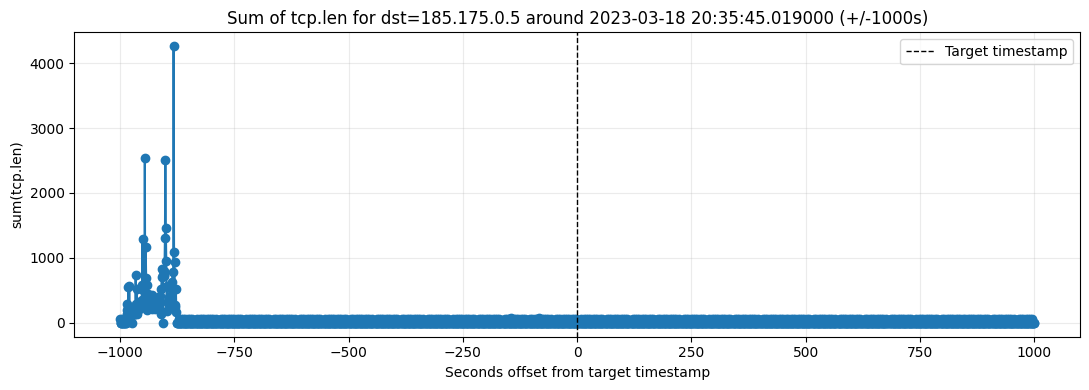

Aligned window: 2023-03-17 00:54:45.989466906 -> 2023-03-17 01:27:59.785640001
Peak bin: 2023-03-17 01:00:22 (-661 s from center)
Peak sum(tcp.len): 259.000000
Rows in window: 9010
Rows with tcp.len > 0 in window: 2320


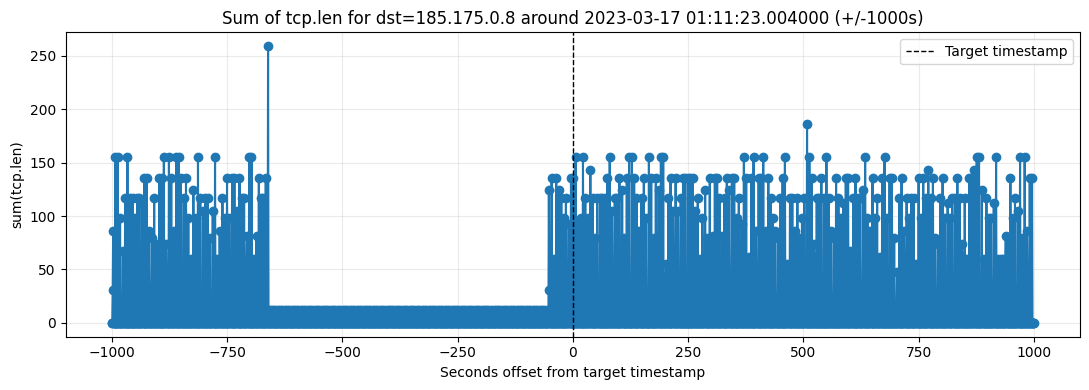

Aligned window: 2023-03-17 02:17:43.133465052 -> 2023-03-17 02:50:59.405507088
Peak bin: 2023-03-17 02:49:22 (+899 s from center)
Peak sum(tcp.len): 259.000000
Rows in window: 6051
Rows with tcp.len > 0 in window: 1131


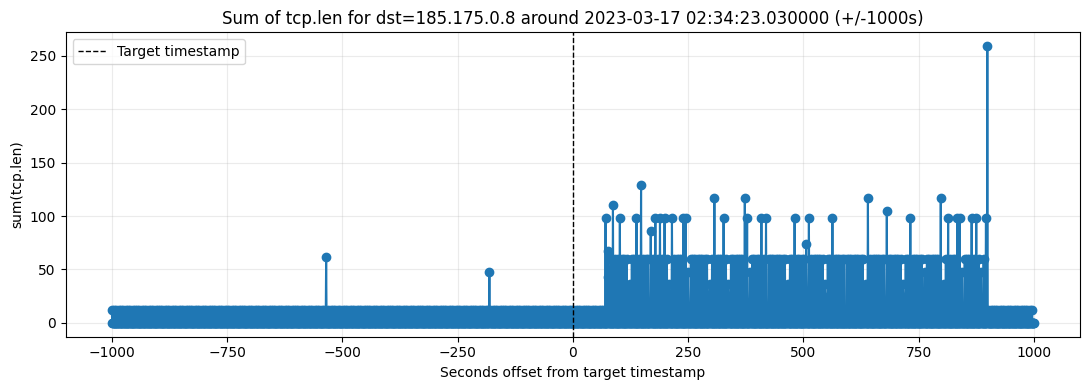

Aligned window: 2023-03-18 00:49:59.721344948 -> 2023-03-18 01:23:17.469978094
Peak bin: 2023-03-18 01:15:46 (+548 s from center)
Peak sum(tcp.len): 167.000000
Rows in window: 7394
Rows with tcp.len > 0 in window: 1848


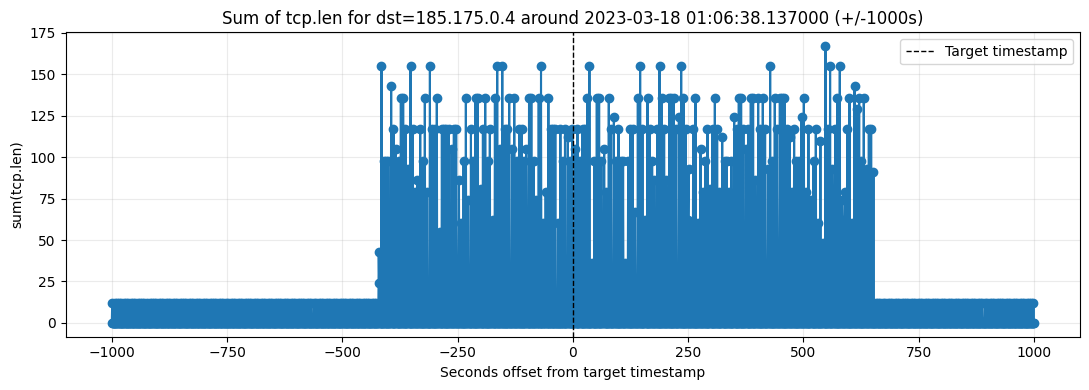

2023-03-18 00:49:58     0.0
2023-03-18 00:49:59    12.0
2023-03-18 00:50:00     0.0
2023-03-18 00:50:01     0.0
2023-03-18 00:50:02     0.0
                       ... 
2023-03-18 01:23:14     0.0
2023-03-18 01:23:15     0.0
2023-03-18 01:23:16     0.0
2023-03-18 01:23:17    12.0
2023-03-18 01:23:18     0.0
Freq: s, Name: tcp.len, Length: 2001, dtype: float64

In [5]:
plot_sum_tcp_len_per_dst_ip("../train/chunks/csc_9.csv", "185.175.0.5", "2023-03-18 20:35:45.019", 1000, debug=True)
plot_sum_tcp_len_per_dst_ip("../train/chunks/csc_3.csv", "185.175.0.8", "2023-03-17 01:11:23.004", 1000, debug=True)
plot_sum_tcp_len_per_dst_ip("../train/chunks/csc_4.csv", "185.175.0.8", "2023-03-17 02:34:23.03", 1000, debug=True) 
plot_sum_tcp_len_per_dst_ip("../train/chunks/csc_6.csv", "185.175.0.4", "2023-03-18 01:06:38.137", 1000, debug=True)

In [29]:
cols = pd.read_csv('../train/cscada_attack_ssw_analysis.csv', nrows=0).columns.tolist()
print("modbus.response_time" in cols)
print("ip.dst" in cols)
print("frame.time_epoch" in cols)

True
True
True


Aligned window: 2023-03-18 20:19:05.109796047 -> 2023-03-18 20:52:21.630111933
Peak bin: 2023-03-18 20:20:17 (-928 s from center)
Peak sum(tcp.analysis.retransmission): 2.000000
Rows in window: 32741
Rows with tcp.analysis.retransmission > 0 in window: 106


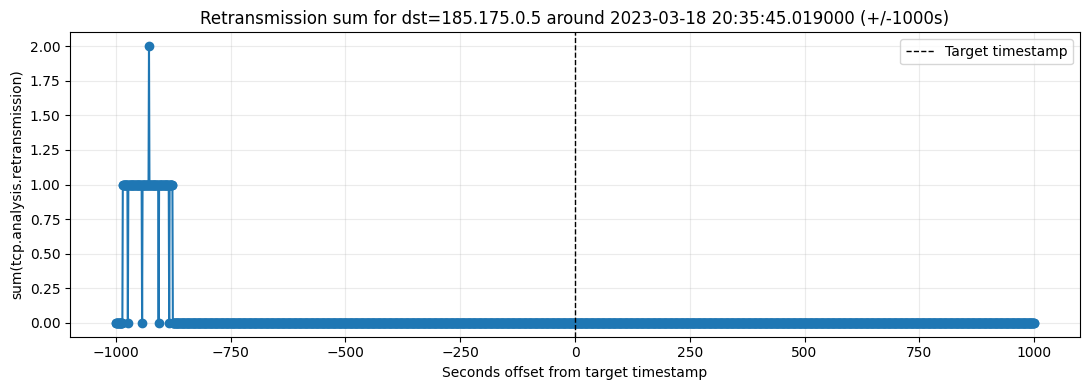

Aligned window: 2023-03-17 00:54:45.989466906 -> 2023-03-17 01:27:59.785640001
Peak bin: 2023-03-17 00:54:43 (-1000 s from center)
Peak sum(tcp.analysis.retransmission): 0.000000
Rows in window: 9010
Rows with tcp.analysis.retransmission > 0 in window: 0


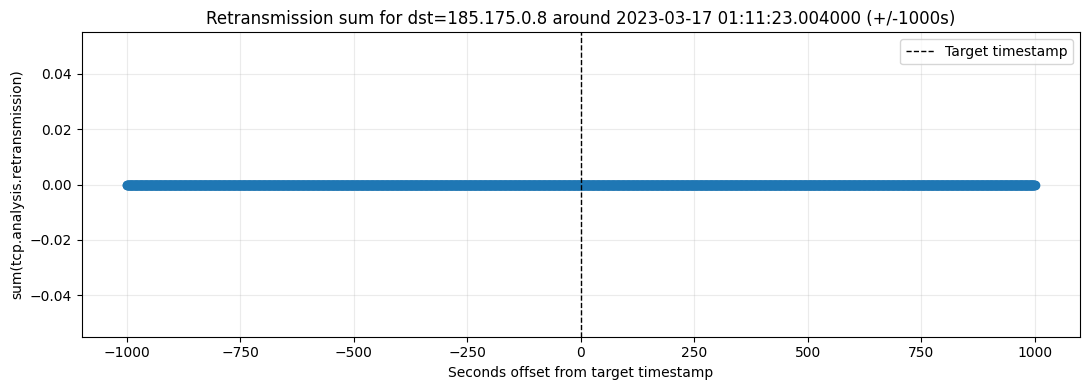

Aligned window: 2023-03-17 02:17:43.133465052 -> 2023-03-17 02:50:59.405507088
Peak bin: 2023-03-17 02:17:43 (-1000 s from center)
Peak sum(tcp.analysis.retransmission): 0.000000
Rows in window: 6051
Rows with tcp.analysis.retransmission > 0 in window: 0


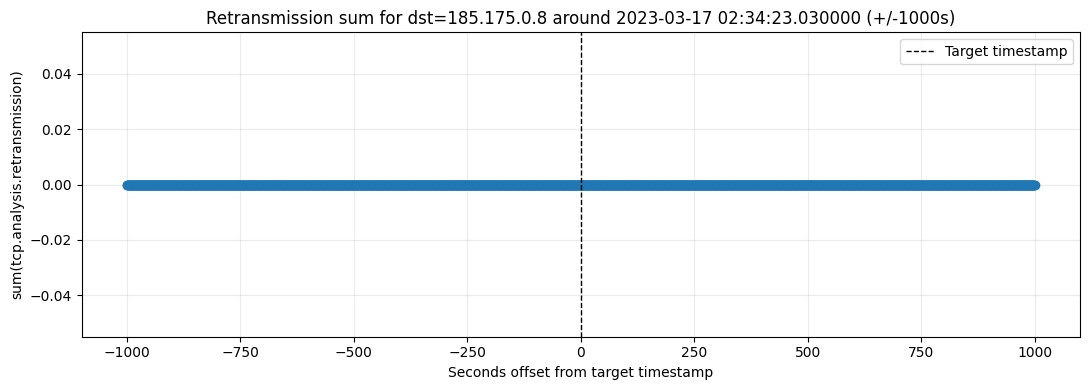

Aligned window: 2023-03-18 00:49:59.721344948 -> 2023-03-18 01:23:17.469978094
Peak bin: 2023-03-18 00:59:38 (-420 s from center)
Peak sum(tcp.analysis.retransmission): 1.000000
Rows in window: 7394
Rows with tcp.analysis.retransmission > 0 in window: 1


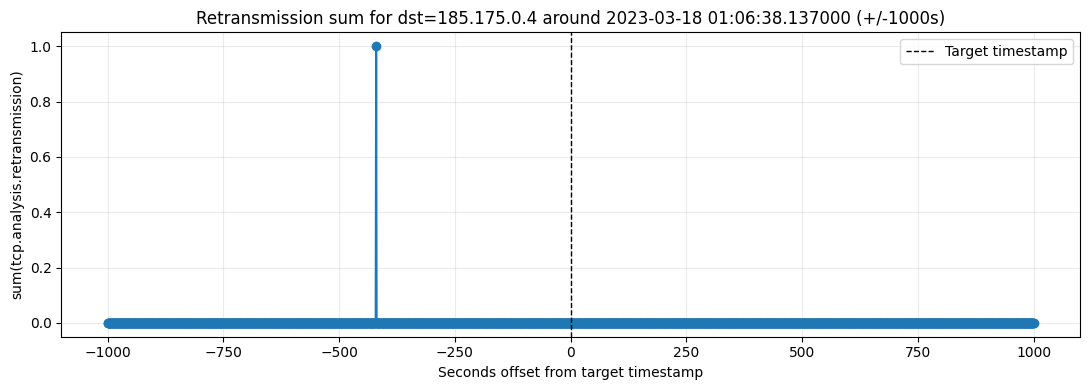

2023-03-18 00:49:58    0.0
2023-03-18 00:49:59    0.0
2023-03-18 00:50:00    0.0
2023-03-18 00:50:01    0.0
2023-03-18 00:50:02    0.0
                      ... 
2023-03-18 01:23:14    0.0
2023-03-18 01:23:15    0.0
2023-03-18 01:23:16    0.0
2023-03-18 01:23:17    0.0
2023-03-18 01:23:18    0.0
Freq: s, Name: retrans_numeric, Length: 2001, dtype: float64

In [7]:
# this is a useless statistic, as response time is not for queries - and this is a query flooding attack
plot_sum_retransmission_per_dst_ip("../train/chunks/csc_9.csv", "185.175.0.5", "2023-03-18 20:35:45.019", 1000, debug=True)
plot_sum_retransmission_per_dst_ip("../train/chunks/csc_3.csv", "185.175.0.8", "2023-03-17 01:11:23.004", 1000, debug=True)
plot_sum_retransmission_per_dst_ip("../train/chunks/csc_4.csv", "185.175.0.8", "2023-03-17 02:34:23.03", 1000, debug=True) 
plot_sum_retransmission_per_dst_ip("../train/chunks/csc_6.csv", "185.175.0.4", "2023-03-18 01:06:38.137", 1000, debug=True)